In [4]:
"""Imports"""
%load_ext autoreload
%autoreload 2

import sys
import os

root = os.path.abspath("..")
if root not in sys.path:
    sys.path.insert(0, root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_raw_data

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
""" Load raw data
"""
df_raw = load_raw_data()
print(f"Raw data loaded: {df_raw.shape}")

Raw data loaded: (5001, 21)


In [6]:
df_raw.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract_type,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,CUST-00005,Male,0,Yes,Yes,53,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Electronic check,29.29,1553.16,No
1,CUST-00001,Male,0,No,Yes,61,Yes,No,Fiber optic,Yes,...,No,No,No,No,Month-to-month,No,Credit card,87.04,5303.45,No
2,CUST-00002,Female,0,No,No,68,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Credit card,28.63,1944.52,No
3,CUST-00003,Male,0,No,NaN,62,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card,27.85,1736.17,No
4,CUST-00004,Male,1,Yes,No,1,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,67.92,62.16,Yes


In [7]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 5001 entries, 0 to 5000
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        5001 non-null   str    
 1   gender             5001 non-null   str    
 2   senior_citizen     5001 non-null   int64  
 3   partner            5001 non-null   str    
 4   dependents         4801 non-null   str    
 5   tenure_months      5001 non-null   int64  
 6   phone_service      5001 non-null   str    
 7   multiple_lines     5001 non-null   str    
 8   internet_service   5001 non-null   str    
 9   online_security    5001 non-null   str    
 10  online_backup      5001 non-null   str    
 11  device_protection  5001 non-null   str    
 12  tech_support       5001 non-null   str    
 13  streaming_tv       5001 non-null   str    
 14  streaming_movies   5001 non-null   str    
 15  contract_type      5001 non-null   str    
 16  paperless_billing  5001 non-null   

In [8]:
df_raw.columns

Index(['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents',
       'tenure_months', 'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract_type',
       'paperless_billing', 'payment_method', 'monthly_charges',
       'total_charges', 'churn'],
      dtype='str')

In [9]:
""" Convert total charges column from object dtype to float dtype
"""

df = df_raw.copy()

df['total_charges'].isna().sum()
df['total_charges'] = pd.to_numeric(df['total_charges'], errors='coerce')
df['total_charges'].values.dtype

dtype('float64')

In [10]:
df[['senior_citizen']].value_counts()

senior_citizen
0                 4276
1                  725
Name: count, dtype: int64

In [11]:
df['senior_citizen'] = df['senior_citizen'].map({0: "No", 1: "Yes"})

In [12]:
df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract_type,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,CUST-00005,Male,No,Yes,Yes,53,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Electronic check,29.29,1553.16,No
1,CUST-00001,Male,No,No,Yes,61,Yes,No,Fiber optic,Yes,...,No,No,No,No,Month-to-month,No,Credit card,87.04,5303.45,No
2,CUST-00002,Female,No,No,No,68,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Credit card,28.63,1944.52,No
3,CUST-00003,Male,No,No,NaN,62,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card,27.85,1736.17,No
4,CUST-00004,Male,Yes,Yes,No,1,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,67.92,62.16,Yes


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5001 entries, 0 to 5000
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        5001 non-null   str    
 1   gender             5001 non-null   str    
 2   senior_citizen     5001 non-null   str    
 3   partner            5001 non-null   str    
 4   dependents         4801 non-null   str    
 5   tenure_months      5001 non-null   int64  
 6   phone_service      5001 non-null   str    
 7   multiple_lines     5001 non-null   str    
 8   internet_service   5001 non-null   str    
 9   online_security    5001 non-null   str    
 10  online_backup      5001 non-null   str    
 11  device_protection  5001 non-null   str    
 12  tech_support       5001 non-null   str    
 13  streaming_tv       5001 non-null   str    
 14  streaming_movies   5001 non-null   str    
 15  contract_type      5001 non-null   str    
 16  paperless_billing  5001 non-null   

In [14]:
""" Impute missing values 
Pass 1: Apply business logic
Pass 2: Statistical approach
        Median, Mean, Mode
"""
mask1 = df['total_charges'].isna()
df[mask1]['tenure_months'].value_counts()

tenure_months
0    64
Name: count, dtype: int64

In [15]:
df.loc[mask1, 'total_charges'] = 0.0

In [16]:
df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract_type,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,CUST-00005,Male,No,Yes,Yes,53,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Electronic check,29.29,1553.16,No
1,CUST-00001,Male,No,No,Yes,61,Yes,No,Fiber optic,Yes,...,No,No,No,No,Month-to-month,No,Credit card,87.04,5303.45,No
2,CUST-00002,Female,No,No,No,68,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Credit card,28.63,1944.52,No
3,CUST-00003,Male,No,No,NaN,62,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card,27.85,1736.17,No
4,CUST-00004,Male,Yes,Yes,No,1,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,67.92,62.16,Yes


In [17]:
df['total_charges'].isna().sum()

np.int64(0)

In [18]:
mean = df['total_charges'].mean()

In [19]:
mask2 = df['total_charges'].isna()
df.loc[mask2, 'total_charges'] = mean

In [20]:
""" Impute categorical missing columns """

categorical_cols = [
    'dependents', 'payment_method'
]

df['payment_method'].isna().sum()

np.int64(150)

In [21]:
mode = df['dependents'].mode()[0]

In [22]:
mask3 = df['dependents'].isna()
df.loc[mask3, 'dependents'] = mode

In [23]:
df[mask3]

,customer_id,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract_type,paperless_billing,payment_method,monthly_charges,total_charges,churn
3,CUST-00003,Male,No,No,No,62,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card,27.85,1736.17,No
72,CUST-00072,Female,Yes,Yes,No,2,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,Month-to-month,Yes,NaN,101.05,206.03,No
157,CUST-00157,Male,No,No,No,68,Yes,No,Fiber optic,Yes,...,No,No,Yes,No,One year,Yes,Mailed check,92.34,6282.56,No
183,CUST-00183,Female,No,Yes,No,56,Yes,No,Fiber optic,No,...,No,Yes,No,No,One year,Yes,Mailed check,91.65,5136.83,No
193,CUST-00193,Male,No,Yes,No,33,No,No phone service,Fiber optic,Yes,...,No,No,Yes,No,Month-to-month,No,Electronic check,83.32,2747.77,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4969,CUST-04969,Male,No,Yes,No,48,Yes,Yes,DSL,No,...,Yes,No,No,Yes,Month-to-month,Yes,Mailed check,70.08,3356.84,Yes
4975,CUST-04975,Female,No,No,No,48,Yes,No,Fiber optic,Yes,...,No,Yes,Yes,No,Month-to-month,Yes,NaN,98.67,4740.46,Yes
4976,CUST-04976,Female,No,Yes,No,53,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Electronic check,28.05,1491.55,No
4990,CUST-04990,Female,No,Yes,No,40,Yes,No,Fiber optic,Yes,...,No,No,No,Yes,Month-to-month,No,Mailed check,93.50,3749.51,No


In [24]:
""" Remove whitespaces from the column values """
df['multiple_lines'].value_counts().keys()

Index(['Yes', 'No', 'No phone service'], dtype='str', name='multiple_lines')

In [25]:
df['multiple_lines'] = df['multiple_lines'].str.strip()

In [26]:
var = '  No  '
var.strip()

'No'

In [62]:
cols = df.select_dtypes(include="object").columns
cols

C:\Users\Ishrat\AppData\Local\Temp\ipykernel_18860\1161580143.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols = df.select_dtypes(include="object").columns


Index(['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents',
       'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract_type',
       'paperless_billing', 'payment_method', 'churn'],
      dtype='str')

In [28]:
for col in cols:
    df[col] = df[col].str.strip()

In [29]:
df.columns = (df.columns
 .str.strip()
 .str.lower()
 .str.replace(' ', '_', regex=False)
 .str.replace('-', '_', regex=False))
df.columns

Index(['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents',
       'tenure_months', 'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract_type',
       'paperless_billing', 'payment_method', 'monthly_charges',
       'total_charges', 'churn'],
      dtype='str')

In [63]:
""" 
Removal of duplicate rows
"""
mask4 = df.duplicated()
df = df.drop_duplicates(keep='first')

df.duplicated().sum()

np.int64(0)

In [31]:
from src.cleaner import run_full_cleaning_pipeline

df_clean, clean_audit = run_full_cleaning_pipeline(df_raw)

In [32]:
df_clean.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract_type,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,CUST-00005,Male,No,Yes,Yes,53,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Electronic check,29.29,1553.16,No
1,CUST-00001,Male,No,No,Yes,61,Yes,No,Fiber optic,Yes,...,No,No,No,No,Month-to-month,No,Credit card,87.04,5303.45,No
2,CUST-00002,Female,No,No,No,68,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Credit card,28.63,1944.52,No
3,CUST-00003,Male,No,No,No,62,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card,27.85,1736.17,No
4,CUST-00004,Male,Yes,Yes,No,1,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,67.92,62.16,Yes


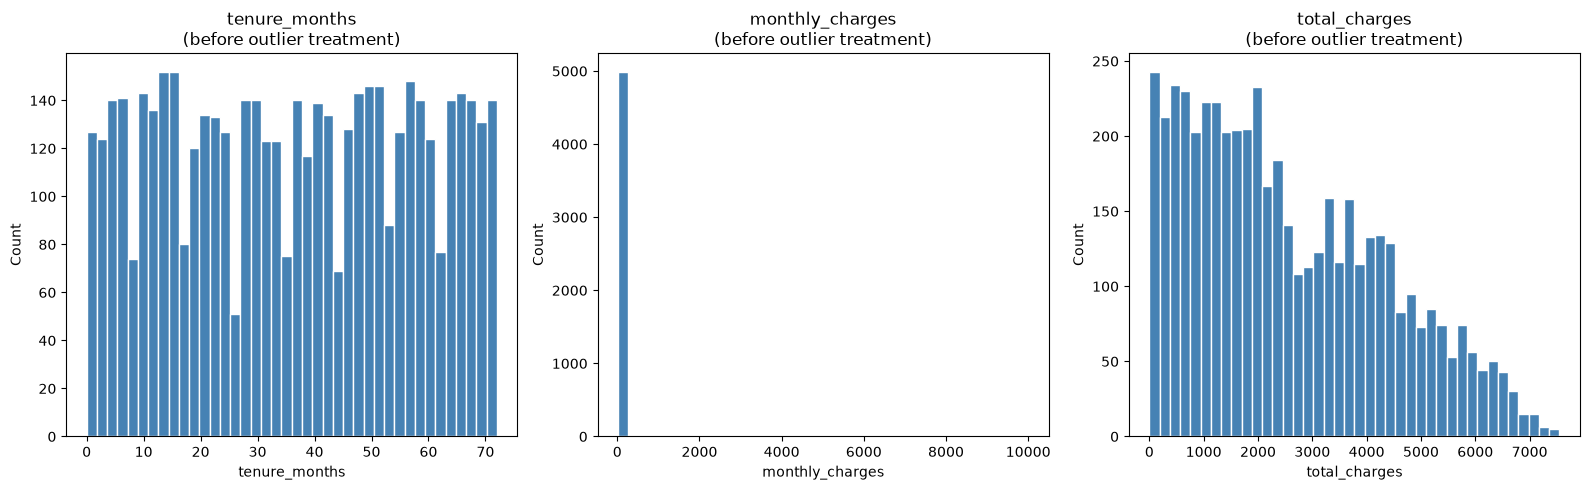

In [64]:
"""Visualise numeric distributions BEFORE outlier treatment"""
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
numeric_cols = ["tenure_months", "monthly_charges", "total_charges"]

for ax, col in zip(axes, numeric_cols):
    ax.hist(df_clean[col], bins=40, color="steelblue", edgecolor="white")
    ax.set_title(f"{col}\n(before outlier treatment)")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.savefig("../reports/figures/distributions_before_outlier_treatment.png", dpi=100)
plt.show()

In [65]:
""" Handling outliers  

Strategy 1: Remove invalid rows
Strategy 2: Winsorization
Strategy 3: Flag Outliers

ages = [1, 25, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 125]
"""

df_clean.head()


,customer_id,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract_type,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,CUST-00005,Male,No,Yes,Yes,53,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Electronic check,29.29,1553.16,No
1,CUST-00001,Male,No,No,Yes,61,Yes,No,Fiber optic,Yes,...,No,No,No,No,Month-to-month,No,Credit card,87.04,5303.45,No
2,CUST-00002,Female,No,No,No,68,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Credit card,28.63,1944.52,No
3,CUST-00003,Male,No,No,No,62,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card,27.85,1736.17,No
4,CUST-00004,Male,Yes,Yes,No,1,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,67.92,62.16,Yes


In [66]:
TENURE_MIN = 0
TENURE_MAX = 72

"""
mask1 = T F T F T T F
mask2 = F F T T T T F

mask1 | mask2 = T F T T T T F
~(mask1 | mask2) = F T F F F F T
"""

mask1 = df_clean['tenure_months'] < TENURE_MIN
mask2 = df_clean['tenure_months'] > TENURE_MAX
indices = df_clean[ mask1 | mask2 ].index.tolist()
df_clean = df_clean[ ~(mask1 | mask2) ]

df_clean.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract_type,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,CUST-00005,Male,No,Yes,Yes,53,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Electronic check,29.29,1553.16,No
1,CUST-00001,Male,No,No,Yes,61,Yes,No,Fiber optic,Yes,...,No,No,No,No,Month-to-month,No,Credit card,87.04,5303.45,No
2,CUST-00002,Female,No,No,No,68,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Credit card,28.63,1944.52,No
3,CUST-00003,Male,No,No,No,62,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card,27.85,1736.17,No
4,CUST-00004,Male,Yes,Yes,No,1,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,67.92,62.16,Yes


In [67]:
df_clean['tenure_months'].value_counts()

tenure_months
53    88
14    84
16    83
51    82
47    81
      ..
39    58
3     56
19    55
26    51
34    50
Name: count, Length: 73, dtype: int64

In [68]:
""" Winsorization 
1 percentile
99 percentile

2.5 percentile
97.5 percentile
-----------------
95% 

1 - 2
2 - 2
3 - 5
4 - 7
5 - 17
6 - 7
7 - 5
8 - 2
9 - 2
"""

df_clean.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract_type,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,CUST-00005,Male,No,Yes,Yes,53,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Electronic check,29.29,1553.16,No
1,CUST-00001,Male,No,No,Yes,61,Yes,No,Fiber optic,Yes,...,No,No,No,No,Month-to-month,No,Credit card,87.04,5303.45,No
2,CUST-00002,Female,No,No,No,68,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Credit card,28.63,1944.52,No
3,CUST-00003,Male,No,No,No,62,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card,27.85,1736.17,No
4,CUST-00004,Male,Yes,Yes,No,1,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,67.92,62.16,Yes


In [69]:
lower_cap = df_clean['monthly_charges'].quantile(1/100)
upper_cap = df_clean['monthly_charges'].quantile(99/100)

print(f'Lower cap: {lower_cap}')
print(f'Upper cap: {upper_cap}')

Lower cap: 19.8858
Upper cap: 106.22660000000005


In [70]:
below_cap = (df['monthly_charges'] < lower_cap).sum()
print(f'Below cap: {below_cap}')

Below cap: 0


In [40]:
above_cap = (df['monthly_charges'] > upper_cap).sum()
above_cap

np.int64(50)

In [71]:
df['monthly_charges'] = df["monthly_charges"].clip(lower_cap, upper_cap)


In [42]:
(df['monthly_charges'] < lower_cap).sum()

np.int64(0)

In [72]:
""" IQR (Interquartile Range)
"""
Q1 = df['monthly_charges'].quantile(0.25)
Q3 = df['monthly_charges'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound)
print(upper_bound)

8.542499999999997
140.1225


In [73]:
df['monthly_charges'] = df["monthly_charges"].clip(lower_bound, upper_bound)

In [45]:
"""Outlier Handling pipeline """
from src.outlier_handler import log_outlier_decisions, run_full_outlier_pipeline

display(log_outlier_decisions())

,column,strategy,threshold,justification
0,tenure_months,remove_invalid_rows,"Valid range: [0, 72]",Values outside 0–72 are physically impossible ...
1,monthly_charges,winsorization,Capped at 1th and 99th percentile,Extreme values are likely anomalies rather tha...
2,total_charges,flag_outliers (IQR method),Q1 - 1.5*IQR to Q3 + 1.5*IQR,High total charges reflect genuine long-tenure...
3,avg_charge_per_month,no action (derived feature),N/A,Derived from monthly_charges (already Winsoriz...


In [75]:
"""Run outlier treatment pipeline and inspect audit trail"""
df_treated, outlier_audit = run_full_outlier_pipeline(df_clean)

print("=== OUTLIER TREATMENT AUDIT TRAIL ===")
for col, result in outlier_audit.items():
    print(f"\n  {col}:")
    for k, v in result.items():
        print(f"    {k}: {v}")

print(f"\nShape after outlier treatment: {df_treated.shape}")

=== OUTLIER TREATMENT AUDIT TRAIL ===

  tenure_months:
    column: tenure_months
    strategy: remove_invalid_rows
    valid_range: [0, 72]
    rows_removed: 0
    removed_indices: []

  monthly_charges:
    column: monthly_charges
    strategy: winsorization
    lower_cap: 19.89
    upper_cap: 106.23
    values_capped_below: 50
    values_capped_above: 50

  total_charges:
    column: total_charges
    strategy: flag_outliers
    iqr_lower_bound: -3196.44
    iqr_upper_bound: 8133.17
    rows_flagged: 0
    flag_column_created: total_charges_outlier_flag

Shape after outlier treatment: (4995, 22)


In [76]:
"""Confirm outlier flag column was created correctly
"""
print("total_charges_outlier_flag distribution:")
print(df_treated["total_charges_outlier_flag"].value_counts())
print(f"\nRows flagged as total_charges outliers: {df_treated['total_charges_outlier_flag'].sum()}")

total_charges_outlier_flag distribution:
total_charges_outlier_flag
0    4995
Name: count, dtype: int64

Rows flagged as total_charges outliers: 0


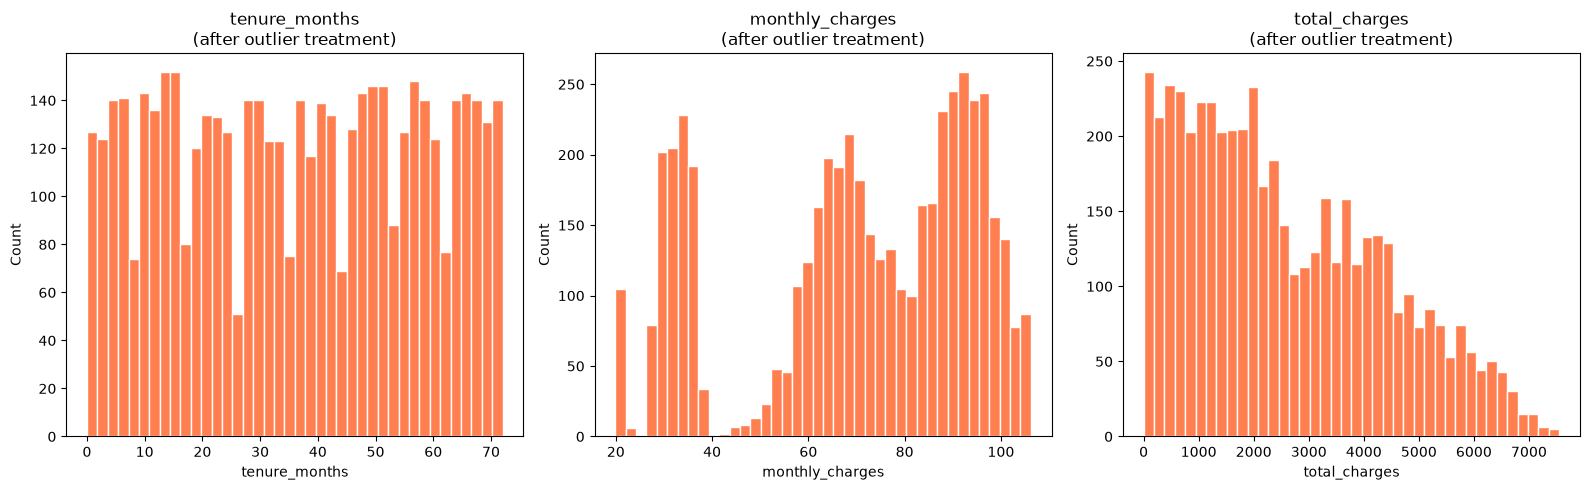

In [77]:
"""Visualise distributions AFTER outlier treatment"""
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, numeric_cols):
    ax.hist(df_treated[col], bins=40, color="coral", edgecolor="white")
    ax.set_title(f"{col}\n(after outlier treatment)")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.savefig("../reports/figures/distributions_after_outlier_treatment.png", dpi=100)
plt.show()

In [49]:
"""
What is a feature?
a feature is an individual, measurable property, characteristic, or variable of the data being analyzed.

What is feature engineering?
feature engineering involves creating new features, transforming transforming, reducing irrelevant features. 

row1: 
customer_id = CUST-00005
gender = Male
senior_citizen = No.
...
...
"""

df_treated.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,...,tech_support,streaming_tv,streaming_movies,contract_type,paperless_billing,payment_method,monthly_charges,total_charges,churn,total_charges_outlier_flag
0,CUST-00005,Male,No,Yes,Yes,53,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,Two year,Yes,Electronic check,29.29,1553.16,No,0
1,CUST-00001,Male,No,No,Yes,61,Yes,No,Fiber optic,Yes,...,No,No,No,Month-to-month,No,Credit card,87.04,5303.45,No,0
2,CUST-00002,Female,No,No,No,68,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,Month-to-month,No,Credit card,28.63,1944.52,No,0
3,CUST-00003,Male,No,No,No,62,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,Two year,Yes,Credit card,27.85,1736.17,No,0
4,CUST-00004,Male,Yes,Yes,No,1,Yes,Yes,DSL,No,...,No,No,Yes,Month-to-month,Yes,Electronic check,67.92,62.16,Yes,0


In [78]:
""" Feature 1: Tenure group

Categories:
New : 0 - 12 months
Mid-term: 13-24 months
Established: 25-48 months
Loyal: 49+ 
"""
bins = [-1, 12, 24, 48, 999999999]
labels = ['New (0-12m)', 'Mid-term (13-24m)', 'Established (25-48m)', 'Loyal (49m+)']

values = pd.cut(
    df_treated['tenure_months'], 
    bins=bins, 
    labels=labels
)

In [51]:
df_treated['tenure_group'] = pd.Categorical(
    values,
    categories=labels,
    ordered=True
)
df_treated.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,...,streaming_tv,streaming_movies,contract_type,paperless_billing,payment_method,monthly_charges,total_charges,churn,total_charges_outlier_flag,tenure_group
0,CUST-00005,Male,No,Yes,Yes,53,Yes,No,No,No internet service,...,No internet service,No internet service,Two year,Yes,Electronic check,29.29,1553.16,No,0,Loyal (49m+)
1,CUST-00001,Male,No,No,Yes,61,Yes,No,Fiber optic,Yes,...,No,No,Month-to-month,No,Credit card,87.04,5303.45,No,0,Loyal (49m+)
2,CUST-00002,Female,No,No,No,68,Yes,No,No,No internet service,...,No internet service,No internet service,Month-to-month,No,Credit card,28.63,1944.52,No,0,Loyal (49m+)
3,CUST-00003,Male,No,No,No,62,Yes,No,No,No internet service,...,No internet service,No internet service,Two year,Yes,Credit card,27.85,1736.17,No,0,Loyal (49m+)
4,CUST-00004,Male,Yes,Yes,No,1,Yes,Yes,DSL,No,...,No,Yes,Month-to-month,Yes,Electronic check,67.92,62.16,Yes,0,New (0-12m)


In [52]:
"""
Feature 2: 
"""

addon_cols = [
    'online_security',
    'online_backup',
    'device_protection',
    'tech_support',
    'streaming_tv',
    'streaming_movies',
]

df_treated['total_addon_services'] = df_treated[addon_cols].apply(
    lambda row: (row == 'Yes').sum(), axis=1
).astype(int)

df_treated.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,...,streaming_movies,contract_type,paperless_billing,payment_method,monthly_charges,total_charges,churn,total_charges_outlier_flag,tenure_group,total_addon_services
0,CUST-00005,Male,No,Yes,Yes,53,Yes,No,No,No internet service,...,No internet service,Two year,Yes,Electronic check,29.29,1553.16,No,0,Loyal (49m+),0
1,CUST-00001,Male,No,No,Yes,61,Yes,No,Fiber optic,Yes,...,No,Month-to-month,No,Credit card,87.04,5303.45,No,0,Loyal (49m+),1
2,CUST-00002,Female,No,No,No,68,Yes,No,No,No internet service,...,No internet service,Month-to-month,No,Credit card,28.63,1944.52,No,0,Loyal (49m+),0
3,CUST-00003,Male,No,No,No,62,Yes,No,No,No internet service,...,No internet service,Two year,Yes,Credit card,27.85,1736.17,No,0,Loyal (49m+),0
4,CUST-00004,Male,Yes,Yes,No,1,Yes,Yes,DSL,No,...,Yes,Month-to-month,Yes,Electronic check,67.92,62.16,Yes,0,New (0-12m),2


In [53]:
""" Feature 3: Average charge per month
total_charges / tenure_months 
"""

df_treated['average_charge_per_month'] = np.where(
    df_treated['tenure_months'] > 0,
    df_treated['total_charges'] / df_treated['tenure_months'],
    df_treated['monthly_charges']
)
df_treated.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,...,contract_type,paperless_billing,payment_method,monthly_charges,total_charges,churn,total_charges_outlier_flag,tenure_group,total_addon_services,average_charge_per_month
0,CUST-00005,Male,No,Yes,Yes,53,Yes,No,No,No internet service,...,Two year,Yes,Electronic check,29.29,1553.16,No,0,Loyal (49m+),0,29.304906
1,CUST-00001,Male,No,No,Yes,61,Yes,No,Fiber optic,Yes,...,Month-to-month,No,Credit card,87.04,5303.45,No,0,Loyal (49m+),1,86.941803
2,CUST-00002,Female,No,No,No,68,Yes,No,No,No internet service,...,Month-to-month,No,Credit card,28.63,1944.52,No,0,Loyal (49m+),0,28.595882
3,CUST-00003,Male,No,No,No,62,Yes,No,No,No internet service,...,Two year,Yes,Credit card,27.85,1736.17,No,0,Loyal (49m+),0,28.002742
4,CUST-00004,Male,Yes,Yes,No,1,Yes,Yes,DSL,No,...,Month-to-month,Yes,Electronic check,67.92,62.16,Yes,0,New (0-12m),2,62.160000


In [54]:
""" Feature 4: Is a new customer """
threshold_months = 3
df_treated['is_new_customer'] = (df_treated['tenure_months'] <= threshold_months).astype(int)

df_treated.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,...,paperless_billing,payment_method,monthly_charges,total_charges,churn,total_charges_outlier_flag,tenure_group,total_addon_services,average_charge_per_month,is_new_customer
0,CUST-00005,Male,No,Yes,Yes,53,Yes,No,No,No internet service,...,Yes,Electronic check,29.29,1553.16,No,0,Loyal (49m+),0,29.304906,0
1,CUST-00001,Male,No,No,Yes,61,Yes,No,Fiber optic,Yes,...,No,Credit card,87.04,5303.45,No,0,Loyal (49m+),1,86.941803,0
2,CUST-00002,Female,No,No,No,68,Yes,No,No,No internet service,...,No,Credit card,28.63,1944.52,No,0,Loyal (49m+),0,28.595882,0
3,CUST-00003,Male,No,No,No,62,Yes,No,No,No internet service,...,Yes,Credit card,27.85,1736.17,No,0,Loyal (49m+),0,28.002742,0
4,CUST-00004,Male,Yes,Yes,No,1,Yes,Yes,DSL,No,...,Yes,Electronic check,67.92,62.16,Yes,0,New (0-12m),2,62.160000,1


In [55]:
""" Feature 5: has any streaming
"""
mask1 = df_treated['streaming_tv'] == 'Yes'
mask2 = df_treated['streaming_movies'] == 'Yes'
df_treated['has_any_streaming'] = (mask1 | mask2).astype(int)
df_treated.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,...,payment_method,monthly_charges,total_charges,churn,total_charges_outlier_flag,tenure_group,total_addon_services,average_charge_per_month,is_new_customer,has_any_streaming
0,CUST-00005,Male,No,Yes,Yes,53,Yes,No,No,No internet service,...,Electronic check,29.29,1553.16,No,0,Loyal (49m+),0,29.304906,0,0
1,CUST-00001,Male,No,No,Yes,61,Yes,No,Fiber optic,Yes,...,Credit card,87.04,5303.45,No,0,Loyal (49m+),1,86.941803,0,0
2,CUST-00002,Female,No,No,No,68,Yes,No,No,No internet service,...,Credit card,28.63,1944.52,No,0,Loyal (49m+),0,28.595882,0,0
3,CUST-00003,Male,No,No,No,62,Yes,No,No,No internet service,...,Credit card,27.85,1736.17,No,0,Loyal (49m+),0,28.002742,0,0
4,CUST-00004,Male,Yes,Yes,No,1,Yes,Yes,DSL,No,...,Electronic check,67.92,62.16,Yes,0,New (0-12m),2,62.160000,1,1


In [56]:
""" Feature 6: Automated Payment

income - expense = savings

income - savings = expense
"""

df_treated['payment_method'].value_counts()

payment_method
Electronic check    1813
Mailed check        1193
Bank transfer        999
Credit card          990
Name: count, dtype: int64

In [57]:
automated_payment_methods = ['Bank transfer', 'Credit card']
df_treated['is_fully_automated_payer'] = (
    df['payment_method'].isin(automated_payment_methods)
).astype(int)

In [58]:
from src.feature_engineer import (
    add_tenure_group,
    add_total_addon_services,
    add_avg_charge_per_month,
    add_is_new_customer,
    add_has_any_streaming,
    add_is_fully_automated_payer,
    get_feature_hypothesis_registry
)

df_featured = df_treated.copy()
df_featured = add_tenure_group(df_featured)
df_featured = add_total_addon_services(df_featured)
df_featured = add_avg_charge_per_month(df_featured)
df_featured = add_is_new_customer(df_featured)
df_featured = add_has_any_streaming(df_featured)
df_featured = add_is_fully_automated_payer(df_featured)

In [59]:
df_featured.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,...,total_charges,churn,total_charges_outlier_flag,tenure_group,total_addon_services,average_charge_per_month,is_new_customer,has_any_streaming,is_fully_automated_payer,avg_charge_per_month
0,CUST-00005,Male,No,Yes,Yes,53,Yes,No,No,No internet service,...,1553.16,No,0,Loyal (49m+),0,29.304906,0,0,0,29.30
1,CUST-00001,Male,No,No,Yes,61,Yes,No,Fiber optic,Yes,...,5303.45,No,0,Loyal (49m+),1,86.941803,0,0,0,86.94
2,CUST-00002,Female,No,No,No,68,Yes,No,No,No internet service,...,1944.52,No,0,Loyal (49m+),0,28.595882,0,0,0,28.60
3,CUST-00003,Male,No,No,No,62,Yes,No,No,No internet service,...,1736.17,No,0,Loyal (49m+),0,28.002742,0,0,0,28.00
4,CUST-00004,Male,Yes,Yes,No,1,Yes,Yes,DSL,No,...,62.16,Yes,0,New (0-12m),2,62.160000,1,1,0,62.16


In [60]:
"""Display the feature hypothesis registry
"""
print("=== FEATURE HYPOTHESIS REGISTRY ===")
display(get_feature_hypothesis_registry())

=== FEATURE HYPOTHESIS REGISTRY ===


,feature,source_columns,business_concept,hypothesis,eda_confirmed
0,tenure_group,tenure_months,Customer lifecycle stage,Churn risk peaks for new customers and decline...,TBD — Class 3
1,total_addon_services,"online_security, online_backup, device_protect...",Service engagement depth,More add-ons = higher switching cost = lower c...,TBD — Class 3
2,avg_charge_per_month,"total_charges, tenure_months, monthly_charges",Effective spend rate,Higher effective spend correlates with price s...,TBD — Class 3
3,is_new_customer,tenure_months,Early churn risk window,First 3 months represent disproportionately hi...,TBD — Class 3
4,has_any_streaming,"streaming_tv, streaming_movies",Entertainment bundle adoption,Streaming users have higher switching cost and...,TBD — Class 3
5,is_fully_automated_payer,payment_method,Payment friction and inertia,Auto-pay customers churn less due to reduced a...,TBD — Class 3


In [61]:
"""Save final processed dataset
"""
PROCESSED_PATH = "../data/processed/telecom_customers_processed.csv"
df_featured.to_csv(PROCESSED_PATH, index=False)
print(f"✅ Processed dataset saved to {PROCESSED_PATH}")
print(f"   Shape   : {df_featured.shape}")
print(f"   Columns : {df_featured.columns.tolist()}")

✅ Processed dataset saved to ../data/processed/telecom_customers_processed.csv
   Shape   : (4995, 29)
   Columns : ['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents', 'tenure_months', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract_type', 'paperless_billing', 'payment_method', 'monthly_charges', 'total_charges', 'churn', 'total_charges_outlier_flag', 'tenure_group', 'total_addon_services', 'average_charge_per_month', 'is_new_customer', 'has_any_streaming', 'is_fully_automated_payer', 'avg_charge_per_month']
